<a href="https://colab.research.google.com/github/Julian27R/Aprendizaje_Maquina/blob/main/FProyecto_Final_TAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
#**Diagnóstico Automatizado de Fallos en Rodamientos Mediante Aprendizaje Automático Aplicado a Señales de Vibración del Dataset CWRU**
###**Por:**
*   **Julián Felipe Gutiérrez Ramírez**
*   **Samuel Marulanda Salazar**
*   **Felipe Idárraga Quintero**

**Fecha de presentación 20/07/2025**



---

#1. **Cargar Base de datos**

In [1]:
!pip install gdown --upgrade --quiet

In [2]:
# -------------------------------
# 1. IMPORTAR LIBRERÍAS
# -------------------------------
import gdown # Para descarga desde Google Drive
import pandas as pd # Para manejo de datos
from IPython.display import display, HTML # Para visualización mejorada

# -------------------------------
# 2. CONFIGURACIÓN INICIAL
# -------------------------------
#https://drive.google.com/file/d/1X2JQUR9axdUeMisbWeZQjfAd37GGnsDk/view?usp=sharing
FILE_ID = "1X2JQUR9axdUeMisbWeZQjfAd37GGnsDk" # ID único del archivo en Drive
NOMBRE_ARCHIVO = "CWRU_Bearing_Dataseet.csv" # Nombre local que tendrá el archivo

# -------------------------------
# 3. DESCARGA DEL ARCHIVO
# -------------------------------
url = f"https://drive.google.com/uc?id={FILE_ID}"
gdown.download(url, NOMBRE_ARCHIVO, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1X2JQUR9axdUeMisbWeZQjfAd37GGnsDk
To: /content/CWRU_Bearing_Dataseet.csv
100%|██████████| 395k/395k [00:00<00:00, 17.9MB/s]


'CWRU_Bearing_Dataseet.csv'

#2. **Lectura de la base de datos con Pandas**

### Identificación del tipo de falla

Hay 10 tipos de fallas, vinculadas a cada defecto del rodamiento:

- **Ball_007_1**: Defecto en la bola (0.007 pulgadas)  
- **Ball_014_1**: Defecto en la bola (0.014 pulgadas)  
- **Ball_021_1**: Defecto en la bola (0.021 pulgadas)  
- **IR_007_1**: Falla en la pista interna (0.007 pulgadas)  
- **IR_014_1**: Falla en la pista interna (0.014 pulgadas)  
- **IR_021_1**: Falla en la pista interna (0.021 pulgadas)  
- **OR_007_6_1**: Falla en la pista externa (0.007 pulgadas, datos recolectados desde la posición de las 6 en punto)  
- **OR_014_6_1**: Falla en la pista externa (0.014 pulgadas, 6 en punto)  
- **OR_021_6_1**: Falla en la pista externa (0.021 pulgadas, 6 en punto)  
- **Normal_1**: Normal  
---

Cada segmento de serie temporal contiene 2048 puntos. Dado que la frecuencia de muestreo es de 48 kHz, cada serie temporal cubre 0.04 segundos.

In [3]:
import numpy as np #importar librerias básicas
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


# fijar semilla para fines pedagógicos
np.random.seed(42)

#render de figs sobre notebook
%matplotlib inline
# para graficar
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

#crear carpeta con resultados
import os
try:
  os.mkdir('results')
except:
  print("Carpeta results ya existe")

import warnings #eliminar warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

In [4]:
CWRU_Bearing_Dataseet = pd.read_csv('CWRU_Bearing_Dataseet.csv')#leer archivo csv con pandas
CWRU_Bearing_Dataseet

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1
...,...,...,...,...,...,...,...,...,...,...
2295,0.21425,-0.19839,0.010769,0.064100,0.064983,-0.212497,-0.119312,3.297037,6.034174,Normal_1
2296,0.21967,-0.20882,0.013136,0.068654,0.069883,-0.061308,-0.295122,3.143410,5.319958,Normal_1
2297,0.20799,-0.21613,0.012571,0.067128,0.068279,-0.154754,-0.071405,3.046161,5.431299,Normal_1
2298,0.21425,-0.22405,0.012608,0.066813,0.067977,-0.326966,0.023662,3.151821,5.391672,Normal_1


###Dimensiones de la Base de Datos sin la Variable Target

In [5]:
x = CWRU_Bearing_Dataseet.drop('fault', axis=1)
y = CWRU_Bearing_Dataseet['fault']
x.shape, y.shape

((2300, 9), (2300,))

### Distribución de clases en el conjunto de datos CWRU (Codificación y Visualización)


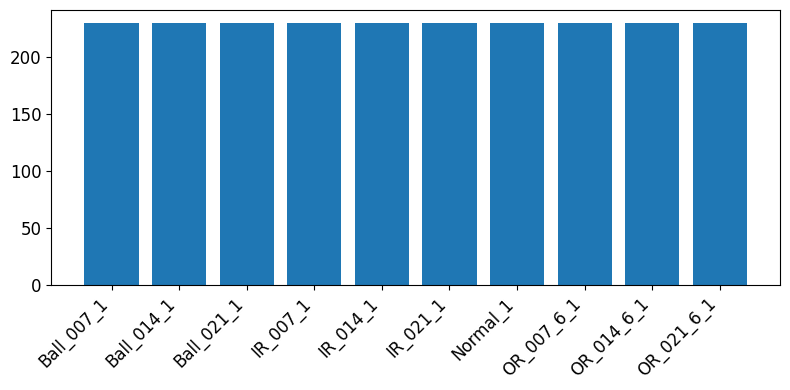

In [6]:
# === Distribución de clases en el conjunto de datos CWRU (Codificación y Visualización) ===

# Codificación de etiquetas: transformar etiquetas categóricas (como nombres de fallos) en valores numéricos
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # y_encoded contendrá los índices numéricos de cada clase

# Contar cuántas muestras hay por cada clase
CWRU_Bearing_Dataseet_counts = pd.DataFrame({
    'label': le.classes_,  # Nombres originales de las clases
    'count': pd.Series(y_encoded).value_counts().sort_index().values  # Conteo de muestras por clase
})

# Visualización de la distribución de clases
plt.figure(figsize=(8,4))  # Definir tamaño de la figura
plt.bar(CWRU_Bearing_Dataseet_counts['label'], CWRU_Bearing_Dataseet_counts['count'])  # Gráfico de barras
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje X para mejor visualización
plt.tight_layout()  # Ajustar márgenes automáticamente
plt.show()  # Mostrar la gráfica


#3. **Se divide el conjunto de datos en entrenamiento y prueba (750 muestras), manteniendo la proporción de clases mediante estratificación.**

In [7]:
train_data, test_data = train_test_split(CWRU_Bearing_Dataseet, test_size = 750, stratify = CWRU_Bearing_Dataseet['fault'], random_state = 1234)
test_data['fault'].value_counts()

,count
fault,
OR_007_6_1,75
IR_014_1,75
OR_014_6_1,75
OR_021_6_1,75
Normal_1,75
IR_021_1,75
Ball_014_1,75
Ball_007_1,75
Ball_021_1,75


In [34]:
train_data

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
1281,2.58390,-2.25870,0.009281,0.637570,0.637482,0.024075,0.430693,4.053292,68.684988,IR_021_1
1623,0.44998,-0.45895,0.013117,0.132720,0.133335,0.028454,0.115373,3.374818,10.165016,OR_014_6_1
514,0.58079,-0.60415,0.012647,0.170700,0.171127,-0.051964,0.700339,3.393918,13.530659,Ball_021_1
68,0.46959,-0.44352,0.017997,0.139225,0.140350,-0.050359,0.199362,3.345853,7.798707,Ball_007_1
1243,1.92030,-2.08090,0.013281,0.577205,0.577217,-0.001174,0.299484,3.326827,43.460212,IR_021_1
...,...,...,...,...,...,...,...,...,...,...
1597,4.83230,-4.87990,0.013384,1.063513,1.063337,0.077378,3.888483,4.544467,79.448795,OR_007_6_1
2253,0.18692,-0.19923,0.014369,0.065699,0.067237,-0.265766,-0.160641,2.780024,4.679176,Normal_1
1032,0.95588,-0.86137,0.030645,0.193692,0.196055,0.068353,1.476947,4.875578,6.397670,IR_014_1
2095,0.20277,-0.20674,0.013441,0.062768,0.064176,-0.168141,-0.081444,3.159578,4.774615,Normal_1


## **4. Normalización de características mediante StandardScaler para conjunto de Entrenamiento (media 0, desviación estándar 1)**

In [30]:
# Scale each column to have zero mean and standard deviation equal to 1
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data.iloc[:,:-1])
pd.DataFrame(train_data_scaled).describe()

,0,1,2,3,4,5,6,7,8
count,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03,1.550000e+03
mean,1.260640e-16,1.002782e-16,-2.888012e-16,6.016693e-17,-5.386372e-17,1.833659e-17,-5.500976e-17,4.950878e-16,-2.521281e-17
std,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00
min,-8.877055e-01,-2.951564e+00,-1.935376e+00,-9.258092e-01,-9.231913e-01,-5.951422e+00,-7.874742e-01,-1.481163e+00,-7.775653e-01
25%,-7.088474e-01,-3.753614e-01,-6.908705e-01,-6.755048e-01,-6.760659e-01,-3.678525e-01,-6.073122e-01,-8.064817e-01,-6.475107e-01
50%,-4.958143e-01,5.113022e-01,-3.141526e-01,-5.055027e-01,-5.038108e-01,2.140248e-01,-4.182916e-01,-2.135605e-01,-4.548003e-01
75%,4.477234e-01,7.003484e-01,4.560105e-01,7.015641e-01,7.003255e-01,5.823124e-01,2.860828e-01,5.648177e-01,4.360429e-01
max,3.297226e+00,8.671141e-01,3.503861e+00,2.980548e+00,2.981995e+00,4.906756e+00,6.349353e+00,4.049712e+00,9.629399e+00


In [10]:
train_data_scaled

array([[ 0.62987013, -0.4396248 , -1.00112845, ..., -0.50499359,
        -0.10126485,  1.40945166],
       [-0.71193169,  0.68109273, -0.40740241, ..., -0.57714644,
        -0.69190307, -0.55347896],
       [-0.6296788 ,  0.59067562, -0.48010234, ..., -0.44329201,
        -0.67527599, -0.44058546],
       ...,
       [-0.39382345,  0.43050284,  2.30565125, ..., -0.26558526,
         0.61456707, -0.67984673],
       [-0.86737652,  0.83814575, -0.35723072, ..., -0.6221828 ,
        -0.87927757, -0.73428873],
       [-0.59386883,  0.53065909, -0.24464364, ..., -0.33676772,
        -0.4265337 , -0.48413186]])

## **5. Normalización de características mediante StandardScaler para conjunto de Prueba (media 0, desviación estándar 1)**

In [28]:
test_data_scaled = (test_data.iloc[:,:-1].values - scaler.mean_)/np.sqrt(scaler.var_)
pd.DataFrame(test_data_scaled).describe()

,0,1,2,3,4,5,6,7,8
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,-0.013718,0.003277,-0.018151,-0.013327,-0.013375,-0.035946,0.018838,0.009379,-0.012433
std,0.976752,0.993896,1.003708,0.987301,0.987315,1.105931,1.028360,0.998996,0.936491
min,-0.895968,-2.754539,-1.590184,-0.922087,-0.922953,-6.014935,-0.759377,-1.515700,-0.772309
25%,-0.706453,-0.429163,-0.720867,-0.677965,-0.678545,-0.355683,-0.606352,-0.762882,-0.641796
50%,-0.494044,0.503185,-0.303458,-0.492809,-0.490457,0.224657,-0.415267,-0.219297,-0.452940
75%,0.394936,0.704214,0.401811,0.669274,0.667916,0.576534,0.294171,0.547845,0.447909
max,3.008545,0.861398,3.003970,2.885914,2.887282,6.301407,5.007205,3.784107,3.531440


# **6.Entrenamiento del modelos**

## **6.1 SVM (Support Vector Classifier) con datos normalizados:**

In [12]:
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.svm import SVC

svc_model = SVC(probability=True)
svc_model.fit(train_data_scaled, train_data['fault'])

SVC(probability=True)

###Búsqueda de hiperparámetros óptimos para SVM mediante GridSearchCV con validación cruzada

In [13]:
parameters = {"C":[1, 10, 45, 47,49, 50, 51, 55, 100, 300, 500],
             'gamma':[0.01, 0.05, 0.1, 0.5, 1, 5],
             'kernel':["rbf"]}

# Define the Grid Search optimization analysis
tuned_svc_clf = GridSearchCV(svc_model,parameters,n_jobs = -1, cv= 10)
tuned_svc_clf.fit(train_data_scaled, train_data['fault'])

# Hyperparameter of the best model
tuned_svc_clf.best_params_

#Let's select the best model and provide results on them
best_clf = tuned_svc_clf.best_estimator_
best_clf

SVC(C=55, gamma=0.05, probability=True)

###Predicciones y evaluación del mejor modelo: Reporte de clasificación y matrices de confusión (Train/Test)

              precision    recall  f1-score   support

  Ball_007_1       0.95      0.99      0.97        75
  Ball_014_1       0.94      0.88      0.91        75
  Ball_021_1       0.97      0.89      0.93        75
    IR_007_1       0.99      1.00      0.99        75
    IR_014_1       1.00      1.00      1.00        75
    IR_021_1       1.00      1.00      1.00        75
    Normal_1       0.97      1.00      0.99        75
  OR_007_6_1       1.00      1.00      1.00        75
  OR_014_6_1       0.84      0.89      0.86        75
  OR_021_6_1       0.99      0.99      0.99        75

    accuracy                           0.96       750
   macro avg       0.96      0.96      0.96       750
weighted avg       0.96      0.96      0.96       750



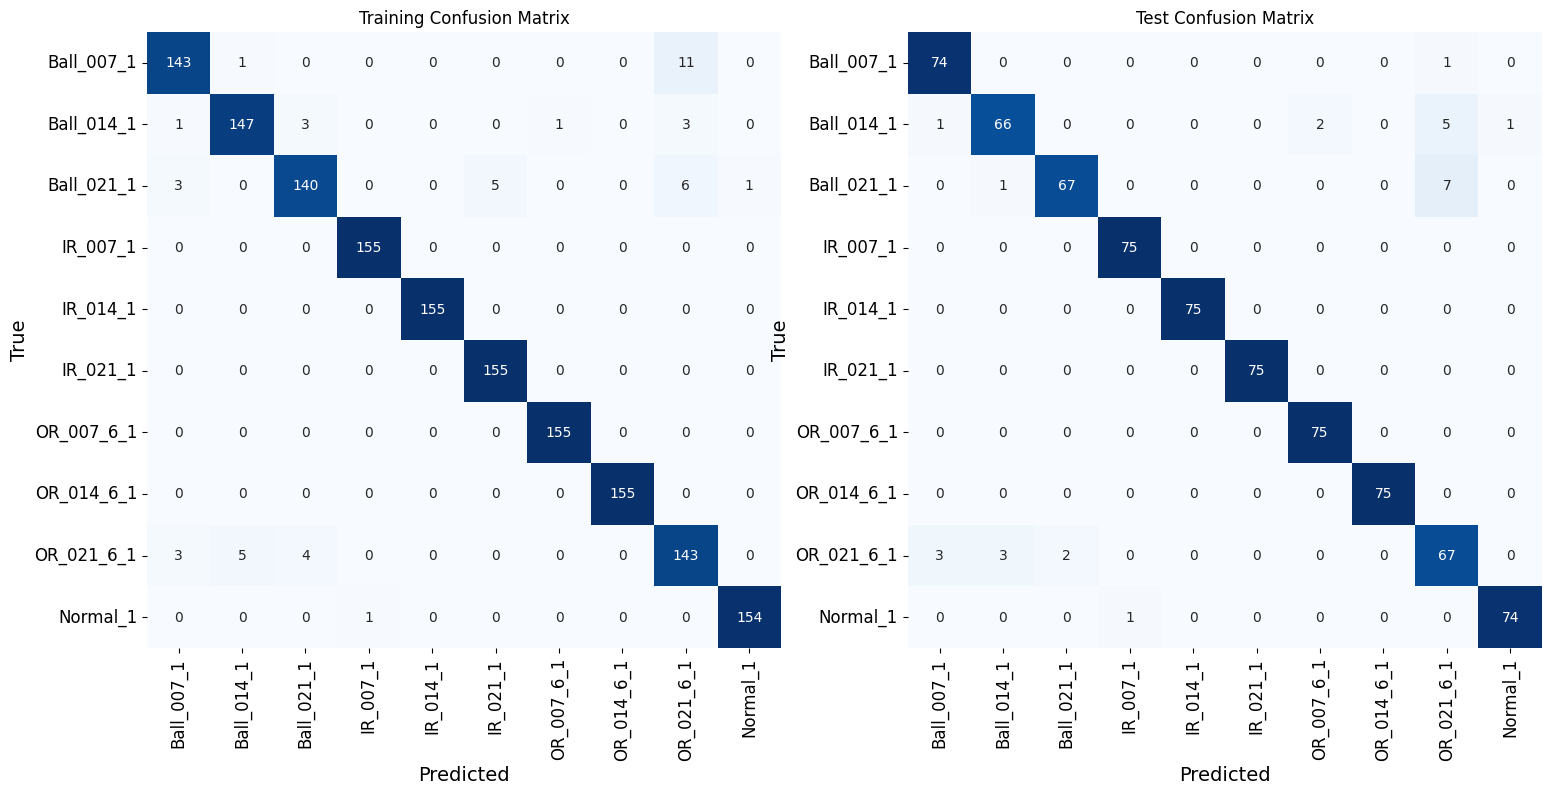

In [14]:
# Compute the predictions
train_predictions_best = best_clf.predict(train_data_scaled)
test_predictions_best = best_clf.predict(test_data_scaled)

train_confu_matrix = confusion_matrix(train_data['fault'], train_predictions_best)
test_confu_matrix = confusion_matrix(test_data['fault'], test_predictions_best)

fault_type = CWRU_Bearing_Dataseet.fault.unique()

# Classification report (test set)
class_report_best = classification_report(y_pred = test_predictions_best, y_true = test_data['fault'])
print(class_report_best)

plt.figure(1,figsize=(18,8))

plt.subplot(121)
sns.heatmap(train_confu_matrix, annot= True,fmt = "d",
xticklabels=fault_type, yticklabels=fault_type, cmap = "Blues", cbar = False)
plt.title('Training Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.subplot(122)

plt.subplot(122)
sns.heatmap(test_confu_matrix, annot = True,
xticklabels=fault_type, yticklabels=fault_type, cmap = "Blues", cbar = False)
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

## **6.2 Entrenamiento del modelo Random Forest con datos normalizados**

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Crear y entrenar el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(train_data_scaled, train_data['fault'])

RandomForestClassifier(random_state=42)

### Búsqueda de hiperparámetros óptimos para Random Forest mediante GridSearchCV con validación cruzada

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Definir la grilla de hiperparámetros
parameters_rf = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Definir el análisis de Grid Search con validación cruzada
tuned_rf_clf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parameters_rf,
    n_jobs=-1,
    cv=10,
    verbose=1
)

# Entrenar el modelo con los datos normalizados
tuned_rf_clf.fit(train_data_scaled, train_data['fault'])

# Mostrar los mejores hiperparámetros encontrados
tuned_rf_clf.best_params_

# Seleccionar el mejor modelo encontrado
best_rf_clf = tuned_rf_clf.best_estimator_
best_rf_clf

Fitting 10 folds for each of 144 candidates, totalling 1440 fits


RandomForestClassifier(min_samples_leaf=2, min_samples_split=10,
                       random_state=42)

###Evaluación del mejor modelo Random Forest: Reporte de clasificación y matrices de confusión


              precision    recall  f1-score   support

  Ball_007_1       0.97      0.96      0.97        75
  Ball_014_1       0.93      0.85      0.89        75
  Ball_021_1       0.89      0.87      0.88        75
    IR_007_1       1.00      1.00      1.00        75
    IR_014_1       1.00      1.00      1.00        75
    IR_021_1       1.00      0.99      0.99        75
    Normal_1       1.00      1.00      1.00        75
  OR_007_6_1       0.99      1.00      0.99        75
  OR_014_6_1       0.84      0.92      0.88        75
  OR_021_6_1       0.96      0.99      0.97        75

    accuracy                           0.96       750
   macro avg       0.96      0.96      0.96       750
weighted avg       0.96      0.96      0.96       750



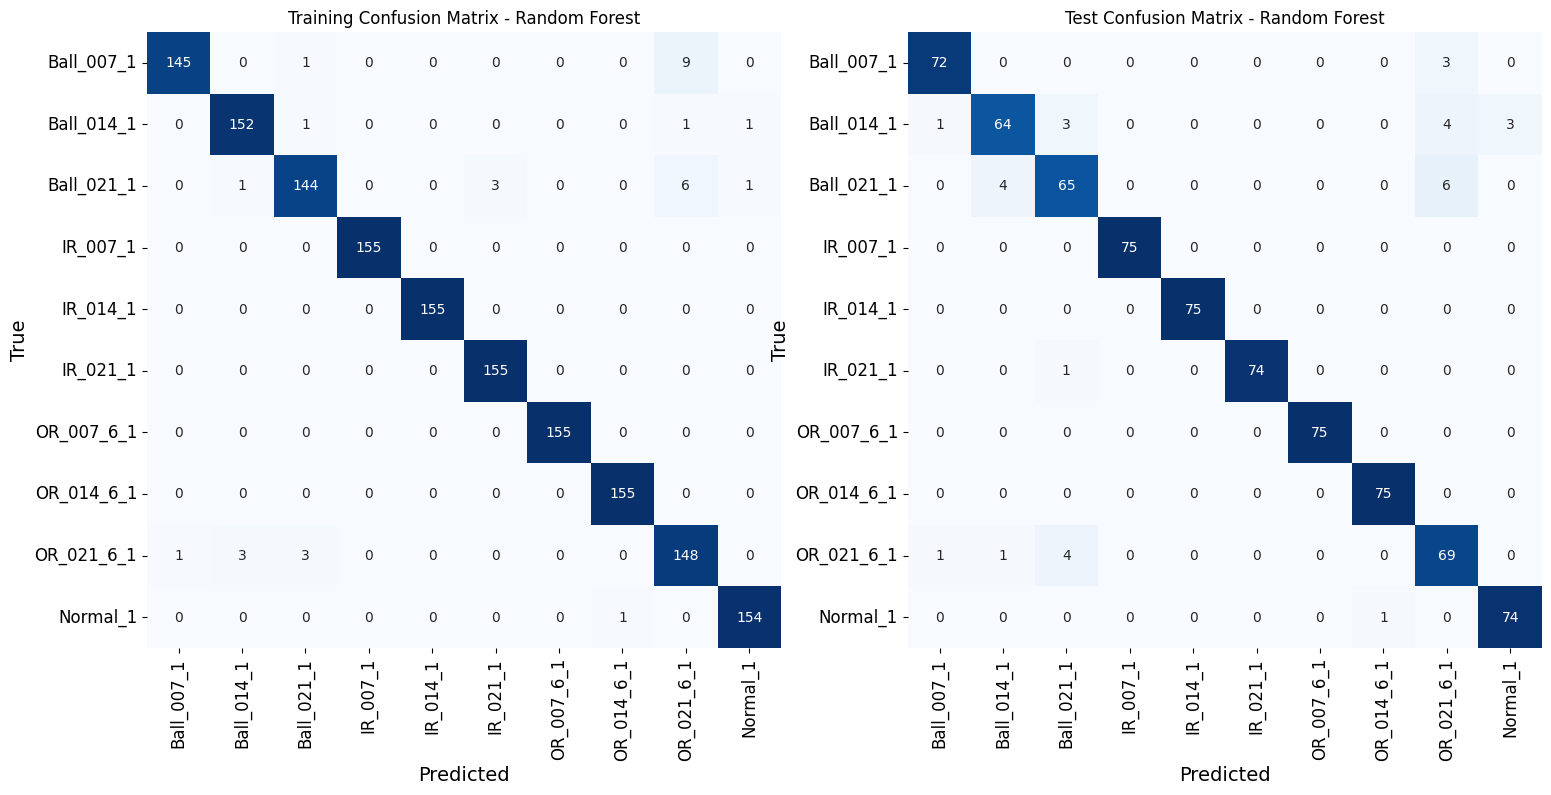

In [17]:
# === Evaluación del mejor modelo Random Forest: Reporte de clasificación y matrices de confusión ===

# Realizar predicciones con el mejor modelo Random Forest
train_predictions_rf = best_rf_clf.predict(train_data_scaled)
test_predictions_rf  = best_rf_clf.predict(test_data_scaled)

# Calcular matrices de confusión
train_confu_matrix_rf = confusion_matrix(train_data['fault'], train_predictions_rf)
test_confu_matrix_rf  = confusion_matrix(test_data['fault'],  test_predictions_rf)

# Obtener nombres de clases (tipos de fallos)
fault_type = CWRU_Bearing_Dataseet.fault.unique()

# Mostrar reporte de clasificación en el conjunto de prueba
class_report_rf = classification_report(y_pred=test_predictions_rf, y_true=test_data['fault'])
print(class_report_rf)

# Visualizar las matrices de confusión
plt.figure(1, figsize=(18, 8))

# Matriz de entrenamiento
plt.subplot(121)
sns.heatmap(train_confu_matrix_rf, annot=True, fmt="d",
            xticklabels=fault_type, yticklabels=fault_type,
            cmap="Blues", cbar=False)
plt.title('Training Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')

# Matriz de prueba
plt.subplot(122)
sns.heatmap(test_confu_matrix_rf, annot=True, fmt="d",
            xticklabels=fault_type, yticklabels=fault_type,
            cmap="Blues", cbar=False)
plt.title('Test Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()


## **6.3 Entrenamiento del modelo Perceptrón Multicapa (MLP)**

E01  loss=1.8263  acc=0.6387
E02  loss=1.2903  acc=0.7467
E03  loss=1.0588  acc=0.7720
E04  loss=0.8760  acc=0.8267
E05  loss=0.7818  acc=0.8320
E06  loss=0.6965  acc=0.8480
E07  loss=0.6359  acc=0.8587
E08  loss=0.5797  acc=0.8747
E09  loss=0.5474  acc=0.8680
E10  loss=0.4950  acc=0.8733
E11  loss=0.5133  acc=0.8800
E12  loss=0.4522  acc=0.8880
E13  loss=0.4520  acc=0.8933
E14  loss=0.4404  acc=0.8933
E15  loss=0.4395  acc=0.8973
E16  loss=0.4266  acc=0.8947
E17  loss=0.4263  acc=0.8947
E18  loss=0.4174  acc=0.9000
E19  loss=0.4065  acc=0.9000
E20  loss=0.3838  acc=0.8987
E21  loss=0.4115  acc=0.9053
E22  loss=0.3999  acc=0.9107
E23  loss=0.3700  acc=0.9093
E24  loss=0.3936  acc=0.9107
E25  loss=0.3957  acc=0.9173
E26  loss=0.3571  acc=0.9133
E27  loss=0.3826  acc=0.9093
E28  loss=0.3576  acc=0.9133
E29  loss=0.3587  acc=0.9133
E30  loss=0.3637  acc=0.9173
E31  loss=0.3538  acc=0.9200
E32  loss=0.3510  acc=0.9173
E33  loss=0.3468  acc=0.9173
E34  loss=0.3539  acc=0.9240
E35  loss=0.35

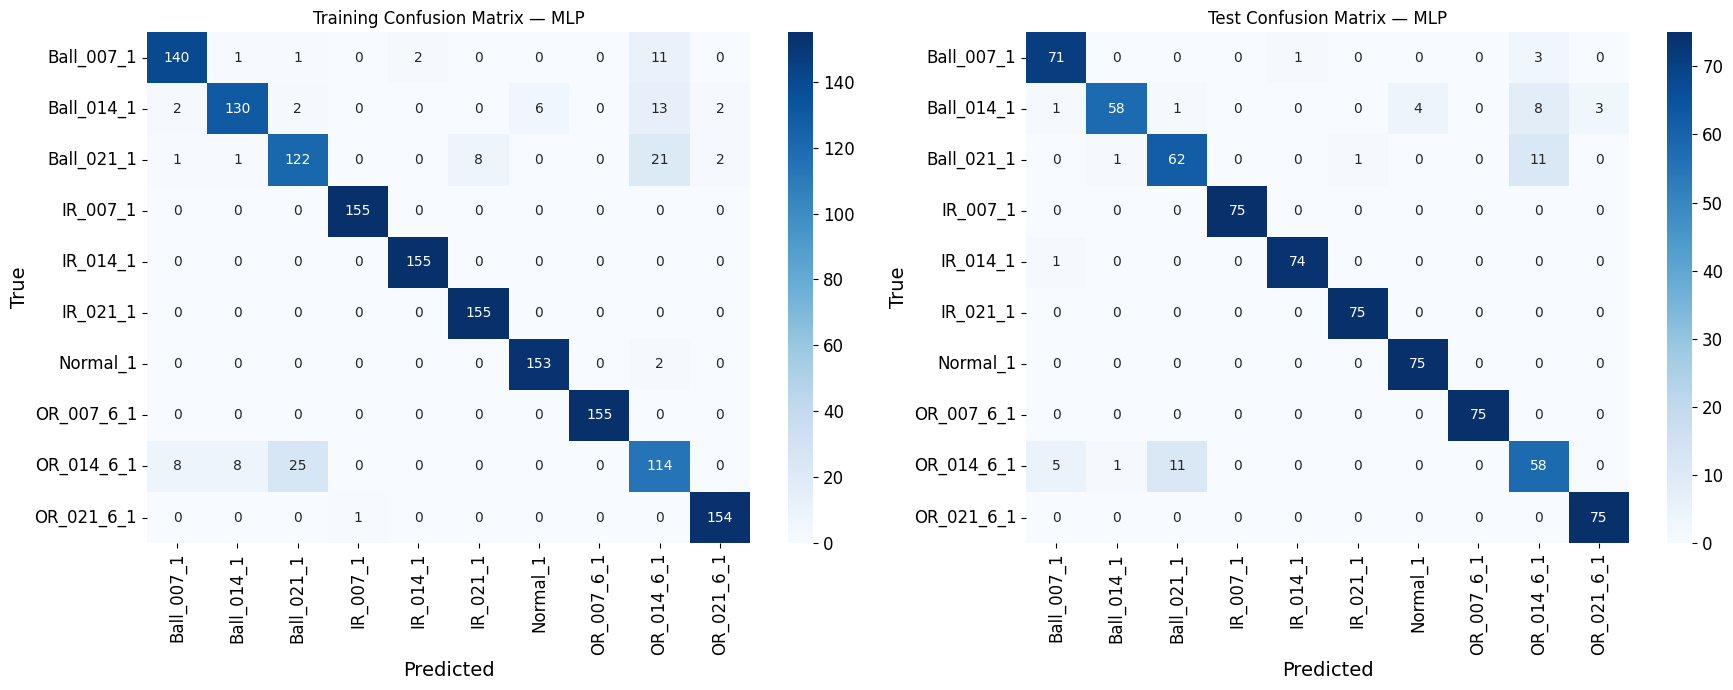

In [48]:
# 1. IMPORTS
import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

# 2. ETIQUETAS (mismo encoder para train y test)
le = LabelEncoder()
le.fit(pd.concat([train_data['fault'], test_data['fault']]))
y_train = le.transform(train_data['fault'])
y_test  = le.transform(test_data['fault'])
class_names = le.classes_.tolist()

# 3. TENSORES Y LOADERS
X_train_raw = train_data.drop(columns=['fault']).values  # 9 features
X_test_raw  = test_data.drop(columns=['fault']).values

X_train_t = torch.tensor(X_train_raw, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_raw,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test , dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=32, shuffle=False)

# 4. MLP (sin cambios)
class MLPClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9, 128), nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )
    def forward(self, x): return self.net(x)

model = MLPClassifier(len(class_names)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
loss_fn   = nn.CrossEntropyLoss()

# 5. ENTRENAMIENTO (con early-stopping)
best_acc, patience, wait = 0.0, 10, 0
for ep in range(1, 80+1):
    # ---- train ----
    model.train(); running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward(); optimizer.step()
        running += loss.item()
    scheduler.step()

    # ---- validate ----
    model.eval(); correct = total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb.to(device)).argmax(1)
            correct += (preds.cpu() == yb).sum().item()
            total   += yb.size(0)
    acc = correct / total
    print(f'E{ep:02d}  loss={running/len(train_loader):.4f}  acc={acc:.4f}')

    # ---- early stop ----
    if acc > best_acc:
        best_acc, wait = acc, 0
        torch.save(model.state_dict(), 'MLP_model_state_dict.pth')
    else:
        wait += 1
        if wait >= patience:
            print(f'🔚  Early stopping at epoch {ep}')
            break

# 6. EVALUACIÓN FINAL DEL MLP (sin escalado)
model.load_state_dict(torch.load('MLP_model_state_dict.pth'))
model.eval()

@torch.no_grad()
def get_preds(loader):
    y_true, y_pred = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(1)
        y_true.extend(yb.numpy())
        y_pred.extend(preds.cpu().numpy())
    return np.array(y_true), np.array(y_pred)

# Obtener predicciones
y_tr_true, y_tr_pred = get_preds(train_loader)
y_te_true, y_te_pred = get_preds(test_loader)

# Reporte de clasificación
print("\n📄 Test classification report")
print(classification_report(y_te_true, y_te_pred,
                            target_names=class_names, digits=4))

# Matrices de confusión
cm_train = confusion_matrix(y_tr_true, y_tr_pred, labels=np.arange(len(class_names)))
cm_test  = confusion_matrix(y_te_true, y_te_pred, labels=np.arange(len(class_names)))

# Visualización con heatmaps
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax[0])
ax[0].set_title('Training Confusion Matrix — MLP')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('True')

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax[1])
ax[1].set_title('Test Confusion Matrix — MLP')
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()



#**App Web con Streamlit**
###1. Instala dependencias en Colab

In [22]:
!pip install -q streamlit scikit-learn pandas joblib torch  # torch solo si usas PyTorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

###2. Exporta el modelo/pipeline

In [23]:
# === 1. Imports necesarios ===
import joblib
import torch
from sklearn.pipeline import Pipeline

# === 2. SVC ===
full_pipeline_svc = Pipeline([
    ('scaler', scaler),          # StandardScaler entrenado
    ('model', best_clf)     # RandomForest entrenado
])
joblib.dump(full_pipeline_svc, 'svc_pipeline.pkl')
print("✅ SVC guardado en 'svc_pipeline.pkl'")

# === 3. Random Forest ===
full_pipeline_rf = Pipeline([
    ('scaler', scaler),          # StandardScaler entrenado
    ('model', best_rf_clf)          # SVC entrenado
])
joblib.dump(full_pipeline_rf, 'rf_pipeline.pkl')
print("✅ Random Forest guardado en 'rf_pipeline.pkl'")

# === 4. MLP (PyTorch) ===
torch.save(model.state_dict(), 'MLP_model_state_dict.pth')  # MLP_model definido y entrenado
print("✅ MLP guardada en 'MLP_model_state_dict.pth'")


✅ SVC guardado en 'svc_pipeline.pkl'
✅ Random Forest guardado en 'rf_pipeline.pkl'
✅ MLP guardada en 'MLP_model_state_dict.pth'


### Decarga de Modelos

In [24]:
from google.colab import files
files.download("rf_pipeline.pkl")
files.download("svc_pipeline.pkl")
files.download("MLP_model_state_dict.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>